In [118]:
import pandas as pd
import numpy as np
from feature.selector import Selective, SelectionMethod
from sklearn.utils import shuffle
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier as KNN
from sklearn.base import BaseEstimator, TransformerMixin
from copy import deepcopy
from sklearn.feature_selection import mutual_info_classif as MIC, SelectKBest
from sklearn.model_selection import train_test_split as tts
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [65]:
def numeric_columns(df):
    numeric_cols = []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
    return numeric_cols
# Load dataset
df = pd.read_csv("impute_mean_classes_no_loc.csv")

# Use function to extract numeric columns
numeric_cols = numeric_columns(df)
# print(df_num.shape)
# print(df_num.columns)
# print(df_num['MHW_count'].value_counts())

# Create a copy of the DataFrame
df_numeric = df[numeric_cols].copy()

# Now you can safely modify df_numeric
df_numeric['mhw_count'] = df_numeric['mhw_count'].astype(str)

df_numeric.loc[df_numeric['mhw_count'].isin(['2', '3']), 'mhw_count'] = '2+'

# Now you can safely modify df_numeric
#df_numeric['mhw_category'] = df['mhw_category']

#print(df_numeric['mhw_category'].value_counts())

print(df_numeric['mhw_count'].value_counts())

# Shuffle the DataFrame
shuffled_df_numeric = shuffle(df_numeric, random_state=42)

# Separate features (X) and labels (y) after shuffling
X = shuffled_df_numeric.drop(['mhw_count'], axis=1)
y = shuffled_df_numeric[['mhw_count']]
X.shape, y.shape

mhw_count
0     3245
1      663
2+     158
Name: count, dtype: int64


((4066, 68), (4066, 1))

In [66]:
class Selective(BaseEstimator, TransformerMixin):
    def __init__(self, selectionmethod):
        self.selectionmethod = selectionmethod
        self.selected_features_ = None
        self.scores_ = None
        
    def fit(self, X, y):
        # Your existing fit implementation
        threshold = self.selectionmethod.threshold
        method = self.selectionmethod.method
        
        # Calculate correlation matrix
        corr_matrix = X.corr(method=method).abs()
        
        # Upper triangle of correlation matrix
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        
        # Find features with correlation < threshold
        self.selected_features_ = [column for column in upper.columns 
                                if any(upper[column] < threshold)]
        
        # If all features are correlated, keep at least one
        if not self.selected_features_:
            self.selected_features_ = [corr_matrix.columns[0]]
            
        # Store correlation scores
        self.scores_ = {col: corr_matrix[col].mean() for col in corr_matrix.columns}
        return self
    
    def transform(self, X):
        return X[self.selected_features_]
    
    def get_absolute_scores(self):
        return self.scores_
    
    def get_params(self, deep=True):
        return {"selectionmethod": self.selectionmethod}
    
    def set_params(self, **params):
        if 'selectionmethod__threshold' in params:
            self.selectionmethod.threshold = params['selectionmethod__threshold']
        if 'selectionmethod__method' in params:
            self.selectionmethod.method = params['selectionmethod__method']
        return self

class SelectionMethod:
    class Correlation:
        def __init__(self, threshold=0.5, method="pearson"):
            self.threshold = threshold
            self.method = method

In [67]:
# Create pipeline
pipeline = Pipeline([
    ('selective', Selective(SelectionMethod.Correlation())),
    ('scaler', StandardScaler()),
    ('classifier', KNN())
])

# Parameter grid
param_grid = {
    'selective__selectionmethod__threshold': np.linspace(0, 1, 20),
    'selective__selectionmethod__method': ['pearson', 'spearman']
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search.fit(X, y.values.ravel())

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best parameters: {'selective__selectionmethod__method': 'pearson', 'selective__selectionmethod__threshold': 0.0}
Best score: 0.9370378765212714


## Variance

In [68]:
class Selective(BaseEstimator, TransformerMixin):
    def __init__(self, selectionmethod=None):
        self.selectionmethod = selectionmethod
        self.selected_features_ = None
        self.scores_ = None
        
    def fit(self, X, y=None):
        # Sørg for at arbejde med numeriske kolonner
        X_num = X.select_dtypes(include=[np.number])
        
        # Varians pr. feature
        variances = X_num.var()
        
        threshold = self.selectionmethod.threshold
        self.selected_features_ = variances[variances > threshold].index.tolist()
        
        # Hvis ingen features opfylder kravet, behold én
        if not self.selected_features_:
            self.selected_features_ = [variances.idxmax()]
        
        self.scores_ = variances.to_dict()
        return self
    
    def transform(self, X):
        return X[self.selected_features_]
    
    def get_absolute_scores(self):
        return self.scores_

class SelectionMethod:
    class Variance(BaseEstimator):
        def __init__(self, threshold=0.0):
            self.threshold = threshold

In [70]:
# Create pipeline
pipeline_var = Pipeline([
    ('selective', Selective(SelectionMethod.Variance())),
    ('scaler', StandardScaler()),
    ('classifier', KNN())
])

# Parameter grid
param_grid_var = {
    'selective__selectionmethod__threshold': np.linspace(0, 10000, 20)
}

# Setup GridSearchCV
grid_search_var = GridSearchCV(
    estimator=pipeline_var,
    param_grid=param_grid_var,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Run grid search
grid_search_var.fit(X, y.values.ravel())

print("Best parameters:", grid_search_var.best_params_)
print("Best score:", grid_search_var.best_score_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'selective__selectionmethod__threshold': 1578.9473684210525}
Best score: 0.9387583826698218


In [71]:
# Feature selectors from simple to more complex
selector_var = Selective(SelectionMethod.Variance(threshold=1579))
# Feature reduction
subset_var = selector_var.fit_transform(X, y)
print("Reduction:", list(subset_var.columns))
print("Scores:", list(selector_var.get_absolute_scores()))

Reduction: ['age', 'functional richness', 'net pp carbon', 'net pp carbon 30', 'particulate organic carbon', 'silva_species_rich', 'sea ice free end', 'sea ice free start', 'silva_chao', 'silva_ace', 'sunshine duration']
Scores: ['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'age', 'chlorophyll a', 'iron std', 'iron', 'functional evenness', 'functional richness', 'max lyapunov exp', 'moon phase prop', 'nitrate and nitrite', 'nitrate and nitrite.1', 'nitrate and nitrite.2', 'nitrate and nitrite.3', 'nitrate and nitrite.4', 'nitrite.5', 'nitrite.1', 'nitrite.2', 'nitrite.3', 'nitrite.4', 'nitrate std', 'net pp carbon', 'net pp carbon 30', 'number of observations', 'okubo-weiss', 'radiation', 'radiation 8.1', 'radiation 8.2', 'radiation 30', 'phosphate', 'phosphate.1', 'phosphate.2', 'phosphate.3', 'phosphate.4', 'particulate inorganic carbon', 'particulate organic carbon', 'residence time', 'silva_species_rich', 'sea ice conc', 'sea ice free days', 'sea ice free end', 

In [72]:
var_df = shuffled_df_numeric[shuffled_df_numeric.columns.difference(subset_var.columns)]
var_df

,ammonium,ammonium std,chlorophyll a,functional evenness,iron,iron std,max lyapunov exp,mhw_count,moon phase prop,nitrate,...,shannon_physat_month,silicate,silicate.1,silicate.2,silicate.3,silicate.4,silva_func_diversity,silva_shannon,strain sub-mesoscale,total suspended matter
2378,0.011647,0.001062,38.337500,0.741793,0.000004,4.280000e-07,0.056329,0,0.00,4.039602,...,0.616444,1.073500,1.109500,1.185750,1.247500,1.276500,7.158554,6.647371,0.000005,0.042097
2420,0.019421,0.014966,58.597400,0.741793,0.000003,1.602000e-06,0.038850,0,0.16,5.954987,...,0.656630,6.399342,6.452702,6.734664,7.235428,7.789695,7.158554,6.647371,0.000009,0.066827
1940,0.018831,0.007324,29.965604,0.741793,0.000945,7.484049e-05,0.079276,0,0.56,1.940813,...,0.616444,6.399342,6.452702,6.734664,7.235428,7.789695,7.158554,6.647371,0.000066,0.120501
1592,0.040871,0.012805,19.840100,0.741793,0.000004,4.470000e-07,0.079276,0,0.45,11.336968,...,0.616444,0.110500,0.110500,0.144500,0.178500,0.178500,7.158554,6.647371,0.000066,0.397447
2283,0.025083,0.011750,30.805800,0.741793,0.000002,1.026000e-06,0.053774,0,0.04,6.231764,...,0.616444,14.723500,15.203250,15.245750,15.313250,18.138750,7.158554,6.647371,0.000003,0.133896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,0.012845,0.000930,26.860900,0.741793,0.001244,7.793400e-05,0.024995,1,0.77,0.012457,...,0.616444,1.278000,1.316500,1.406500,1.524500,1.591000,7.158554,6.647371,0.000001,0.057862
1294,0.012506,0.006803,14.851300,0.741793,0.000805,9.725200e-05,0.045517,0,0.28,0.003165,...,0.616444,0.486000,0.486000,0.759500,1.033000,1.033000,7.158554,6.647371,0.000018,0.045416
860,0.012245,0.000652,16.843700,0.741793,0.001074,1.095600e-04,0.147680,1,0.93,0.014058,...,0.786314,10.550000,10.550000,10.550000,10.550000,10.550000,7.158554,6.647371,0.000025,0.066230
3507,0.014199,0.009693,29.965604,0.741793,0.000990,3.298130e-04,0.036693,0,0.13,8.367322,...,0.616444,0.652160,0.652160,0.652160,0.652160,0.652160,7.158554,6.647371,0.000066,0.161839


## Mutual info 

In [87]:
# calculate mutual information
scores = MIC(X, y.ravel(), random_state = 24)

X_new = SelectKBest(MIC, k=10).fit(X, y.ravel())

print('scores:', scores)
print(X_new.get_feature_names_out())

# Alle scores
all_scores = X_new.scores_

#Hent index for de 5 bedste features
top5_indices = X_new.get_support(indices=True)

# Hent de 5 score værdier
top5_scores = all_scores[top5_indices]

# (Valgfrit) Hent feature-navne hvis X er DataFrame
top5_feature_names = X.columns[top5_indices]

# Print
for name, score in zip(top5_feature_names, top5_scores):
    print(f"{name}: {score:.4f}")

scores: [0.47124422 0.4704297  0.46889482 0.47326758 0.46971779 0.11775641
 0.43705079 0.43250228 0.46771926 0.04989569 0.06093708 0.36425567
 0.21461305 0.19396063 0.17310023 0.19823386 0.20373542 0.23109513
 0.14309683 0.14612172 0.14538494 0.16710366 0.18502218 0.46637963
 0.01138011 0.03926693 0.02264239 0.42923815 0.40539409 0.46129773
 0.40172307 0.47082364 0.19871771 0.17882781 0.19085276 0.20123131
 0.22694285 0.29292826 0.31183927 0.22607863 0.05058184 0.00936314
 0.03118651 0.04162581 0.03455337 0.24982883 0.22190434 0.23052579
 0.22644388 0.25191621 0.05206132 0.04481647 0.04487674 0.15477794
 0.15167634 0.15519329 0.15328055 0.15430318 0.15984287 0.37047464
 0.27873775 0.02771471 0.40208256 0.40376512 0.44917362 0.46493511
 0.33966611 0.04692483]
['ammonium' 'ammonium std' 'nitrite' 'nitrite std' 'nitrate' 'iron'
 'nitrate std' 'radiation 8.1' 'radiation 30' 'sea surface temp']
ammonium: 0.4721
ammonium std: 0.4719
nitrite: 0.4685
nitrite std: 0.4741
nitrate: 0.4650
iron: 0

In [74]:
knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)

class MutualInfoSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.1):
        self.threshold = threshold
        self.selected_features_ = None
        
    def fit(self, X, y):
        mi_scores = MIC(X, y, random_state = 42)
        self.selected_features_ = np.where(mi_scores > self.threshold)[0]
        return self
    
    def transform(self, X):
        return X.iloc[:, self.selected_features_]

# Create pipeline
pipe = Pipeline([
    ('selector', MutualInfoSelector()),
    ('clf', clf)  # Your classifier
])
y = y.values.ravel()
# Grid search parameters
param_grid = {
    'selector__threshold': np.linspace(0, 0.5, 20)
}

grid_search = GridSearchCV(pipe, param_grid, cv = 5, scoring='accuracy')
grid_search.fit(X, y)
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)
# After fitting

df_cv = pd.DataFrame(grid_search.cv_results_)
df_cv

C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
8 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "C:\Users\hamid\anaconda3\envs\amlfall24\lib\site-packages\sklearn\pipeline.py", line 473, in fit
    self._final_esti

Best parameters: {'selector__threshold': 0.4473684210526315}
Best score: 0.9643384075118393


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_selector__threshold,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,1.021624,0.139948,0.084688,0.011551,0.000000,{'selector__threshold': 0.0},0.931204,0.915129,0.940959,0.926199,0.910209,0.924740,0.011050,18
1,1.008342,0.131249,0.078063,0.012698,0.026316,{'selector__threshold': 0.02631578947368421},0.929975,0.917589,0.940959,0.921279,0.913899,0.924740,0.009707,17
2,1.032050,0.104168,0.087989,0.023403,0.052632,{'selector__threshold': 0.05263157894736842},0.932432,0.916359,0.939729,0.929889,0.915129,0.926708,0.009525,16
3,1.007463,0.120428,0.066075,0.006905,0.078947,{'selector__threshold': 0.07894736842105263},0.934889,0.917589,0.939729,0.929889,0.921279,0.928675,0.008245,13
4,0.992329,0.150813,0.072234,0.013242,0.105263,{'selector__threshold': 0.10526315789473684},0.934889,0.917589,0.937269,0.923739,0.921279,0.926953,0.007741,15
5,0.969087,0.102063,0.086692,0.026963,0.131579,{'selector__threshold': 0.13157894736842105},0.933661,0.923739,0.937269,0.923739,0.920049,0.927692,0.006588,14
6,0.964450,0.143857,0.082167,0.010710,0.157895,{'selector__threshold': 0.15789473684210525},0.950860,0.923739,0.952030,0.937269,0.928659,0.938511,0.011420,12
7,0.980638,0.164145,0.073950,0.014796,0.184211,{'selector__threshold': 0.18421052631578946},0.953317,0.942189,0.956950,0.942189,0.945879,0.948105,0.006006,11
8,0.986058,0.080735,0.068421,0.012006,0.210526,{'selector__threshold': 0.21052631578947367},0.954545,0.950800,0.963100,0.956950,0.948339,0.954747,0.005124,10
9,0.998755,0.123043,0.069399,0.005991,0.236842,{'selector__threshold': 0.23684210526315788},0.958231,0.956950,0.970480,0.958180,0.956950,0.960158,0.005191,9


In [89]:
# 1. First select features
mi_score_selected_index = np.where(scores >0.4473)[0]
X_2 = X.iloc[:,mi_score_selected_index]
X_2

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp
2378,0.011647,0.001062,0.006479,0.001361,4.039602,0.000004,1.021912,46.347424,45.408386,0.245140,26.686632
2420,0.019421,0.014966,0.036846,0.047819,5.954987,0.000003,1.244382,50.930030,54.287350,0.167470,27.159315
1940,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,52.996185,53.979880,1.040722,24.200793
1592,0.040871,0.012805,0.175246,0.095507,11.336968,0.000004,1.000068,40.447495,43.392790,2.105800,18.466765
2283,0.025083,0.011750,0.054778,0.047893,6.231764,0.000002,0.853389,46.940914,45.790096,1.040722,26.730190
...,...,...,...,...,...,...,...,...,...,...,...
1130,0.012845,0.000930,0.029691,0.004530,0.012457,0.001244,0.004551,47.209393,43.349780,0.255560,23.675053
1294,0.012506,0.006803,0.005806,0.004141,0.003165,0.000805,0.002556,52.275124,54.200054,2.000300,24.192727
860,0.012245,0.000652,0.002289,0.000248,0.014058,0.001074,0.004599,41.299805,41.682808,0.282200,29.767761
3507,0.014199,0.009693,0.025725,0.011551,8.367322,0.000990,3.924304,30.019270,30.199345,1.040722,4.301265


In [147]:
df_1 = pd.read_csv('impute_mean_classes_new.csv')

In [149]:
df_final = df_1[['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'iron',
'nitrate std', 'radiation 8.1', 'radiation 30', 'sea surface temp grad', 'sea surface temp', 'mhw_count', 
                 'latitude', 'longitude', 'depth, nominal', 'date/time']].drop_duplicates(inplace = False)
df_final

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count,latitude,longitude,"depth, nominal",date/time
0,0.017782,0.003814,0.033199,0.021603,0.006594,0.001293,0.002778,32.308980,34.751957,0.391360,18.633288,0,44.4013,-9.8273,0-500,2009-09-07T15:30
1,0.017782,0.003814,0.033199,0.021603,0.006594,0.001293,0.002778,32.308980,34.751957,0.391360,18.633288,0,44.4013,-9.8273,9,2009-09-07T16:10
2,0.019857,0.004334,0.022540,0.003445,0.004371,0.001387,0.001121,37.966010,40.183044,1.340400,20.026061,0,39.0564,-10.9808,0-200,2009-09-09T18:30
3,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,45.094790,43.211200,0.427630,21.362549,0,36.7320,-10.4750,9,2009-09-13T11:30
4,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,45.094790,43.211200,0.427630,21.362549,0,36.7320,-10.4750,9,2009-09-13T12:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4061,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,6.981609,7.406619,1.040722,12.249180,0,48.7130,-38.8121,2,2013-11-29T11:13
4062,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,7.046190,4.401833,1.040722,12.046478,0,49.8982,-27.4226,2,2013-12-01T15:38
4063,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,8.169573,5.551019,1.040722,12.308273,1,49.9416,-22.8470,2,2013-12-02T14:16
4064,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,3.313076,4.240282,1.040722,19.983051,0,49.6001,-17.4584,2,2013-12-03T15:23


In [151]:
df_test = df_1[['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'iron',
'nitrate std', 'radiation 8.1', 'radiation 30', 'sea surface temp grad', 'sea surface temp', 'mhw_count']].drop_duplicates(inplace = False)
df_test

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count
0,0.017782,0.003814,0.033199,0.021603,0.006594,0.001293,0.002778,32.308980,34.751957,0.391360,18.633288,0
2,0.019857,0.004334,0.022540,0.003445,0.004371,0.001387,0.001121,37.966010,40.183044,1.340400,20.026061,0
3,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,45.094790,43.211200,0.427630,21.362549,0
5,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,44.302357,42.952587,0.442470,21.249980,0
6,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,45.094790,43.211200,0.442470,21.362549,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4061,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,6.981609,7.406619,1.040722,12.249180,0
4062,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,7.046190,4.401833,1.040722,12.046478,0
4063,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,8.169573,5.551019,1.040722,12.308273,1
4064,0.018831,0.007324,0.057298,0.028184,1.940813,0.000945,0.654520,3.313076,4.240282,1.040722,19.983051,0


In [154]:
real = df_final.drop(['latitude', 'longitude', 'depth, nominal', 'date/time'], axis = 1)
real.to_csv('12 features - MI dataset.csv', index = False)

(1896, 11) (1896,) (475, 11) (475,)
cross validation scores: [0.90736842 0.93459916 0.94092827 0.90084388 0.91772152]
0.9203 accuracy with a standard deviation of 0.0154
Accuracy: 91.16%
[[356  17   2   0]
 [ 16  66   0   0]
 [  3   2  10   2]
 [  0   0   0   1]]
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       375
           1       0.78      0.80      0.79        82
           2       0.83      0.59      0.69        17
           3       0.33      1.00      0.50         1

    accuracy                           0.91       475
   macro avg       0.72      0.84      0.73       475
weighted avg       0.91      0.91      0.91       475



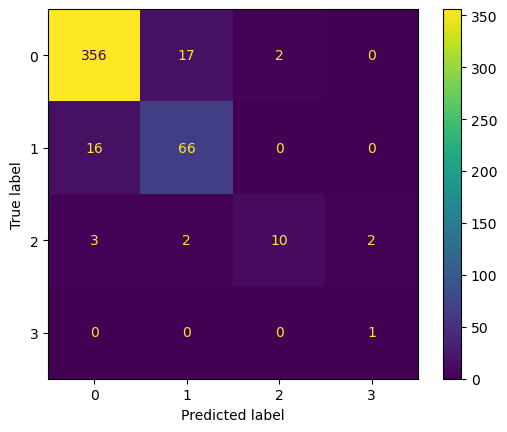

In [146]:
# Shuffle the DataFrame
shuffled_df = shuffle(real, random_state=42)

# Separate features (X) and labels (y) after shuffling
X_imp = shuffled_df.drop(['mhw_count'], axis=1)
y_imp = shuffled_df['mhw_count']

X_train, X_test, y_train, y_test = tts(
    X_imp, y_imp, stratify = y_imp, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape,
X_test.shape, y_test.shape)

knn = KNN()
clf = Pipeline(
    steps=[("scaler", StandardScaler()), ("knn", knn)]
)
clf.fit(X_train, y_train)

cross_val_scores = cross_val_score(clf, X_imp, y_imp, cv=5)
print('cross validation scores:', cross_val_scores)
print("%0.4f accuracy with a standard deviation of %0.4f" % (cross_val_scores.mean(), cross_val_scores.std()))

y_pred = clf.predict(X_test)
prob_pred = clf.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
print(cm)
#disp = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'pred')
#disp_2 = ConfusionMatrixDisplay.from_estimator(forest, X_test, y_test, normalize = 'true')
disp_3 = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
#disp_2.plot()
print(classification_report(y_test, y_pred))

In [50]:
df.var().nlargest(10)

functional richness           738775.066351
silva_ace                     148769.818192
silva_chao                    146948.774267
net pp carbon 30               57069.113188
sunshine duration              46714.190709
silva_species_rich             41263.590851
net pp carbon                  18943.547127
particulate organic carbon     13800.392567
sea ice free end                4976.953687
sea ice free start              2762.310829
dtype: float64

In [156]:
df_un = pd.read_csv('TARA_mhws_3.csv')
df_un.shape

(4066, 94)

In [158]:
df_unin = df_un[['ammonium', 'ammonium std', 'nitrite', 'nitrite std', 'nitrate', 'iron',
'nitrate std', 'radiation 8.1', 'radiation 30', 'sea surface temp grad', 'sea surface temp', 'mhw_count']]
df_unin

,ammonium,ammonium std,nitrite,nitrite std,nitrate,iron,nitrate std,radiation 8.1,radiation 30,sea surface temp grad,sea surface temp,mhw_count
0,0.017782,0.003814,0.033199,0.021603,0.006594,0.001293,0.002778,32.308980,34.751957,0.39136,18.633288,0
1,0.017782,0.003814,0.033199,0.021603,0.006594,0.001293,0.002778,32.308980,34.751957,0.39136,18.633288,0
2,0.019857,0.004334,0.022540,0.003445,0.004371,0.001387,0.001121,37.966010,40.183044,1.34040,20.026061,0
3,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,45.094790,43.211200,0.42763,21.362549,0
4,0.019621,0.001549,0.049836,0.016420,0.008997,0.001387,0.004591,45.094790,43.211200,0.42763,21.362549,0
...,...,...,...,...,...,...,...,...,...,...,...,...
4061,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.981609,7.406619,NaN,12.249180,0
4062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.046190,4.401833,NaN,12.046478,0
4063,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.169573,5.551019,NaN,12.308273,1
4064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.313076,4.240282,NaN,NaN,0


In [160]:
df_unin.to_csv('12 features - no imp.csv', index = False)